In [1]:
import numpy as np
import pandas as pd
import pickle
import seaborn as sns
from matplotlib import pyplot as plt
from xgboost import XGBClassifier as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold

In [2]:
%matplotlib inline

**Loading and Cleaning of Dataset**

In [3]:
df = pd.read_csv(r"C:\Users\Admin\Jupyter_Note_folder\Data Science Projects\data\Customer Churn.csv")

df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [4]:
# checking for null values
df.isnull().sum()

Call  Failure              0
Complains                  0
Subscription  Length       0
Charge  Amount             0
Seconds of Use             0
Frequency of use           0
Frequency of SMS           0
Distinct Called Numbers    0
Age Group                  0
Tariff Plan                0
Status                     0
Age                        0
Customer Value             0
Churn                      0
dtype: int64

In [5]:
# checking for duplicates
df.duplicated().sum()

np.int64(300)

In [6]:
df[df.duplicated()]

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
518,0,0,37,0,0,0,0,0,2,1,2,25,0.00,1
628,0,0,35,0,0,0,0,0,2,1,2,25,0.00,1
718,0,0,37,0,0,0,0,0,2,1,2,25,0.00,1
728,0,0,36,0,0,0,0,0,3,1,2,30,0.00,1
901,0,0,38,0,0,0,0,0,2,1,2,25,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3145,21,0,19,2,6697,147,92,44,2,2,1,25,721.98,0
3146,17,0,17,1,9237,177,80,42,5,1,1,55,261.21,0
3147,13,0,18,4,3157,51,38,21,3,1,1,30,280.32,0
3148,7,0,11,2,4695,46,222,12,3,1,1,30,1077.64,0


In [7]:
# drop duplicates
df.drop_duplicates(inplace=True)

In [8]:
df.rename(columns={
    'Call  Failure': 'Call Failure', 
    'Subscription  Length': 'Subscription Length', 
    "Charge  Amount": "Charge Amount"},
    inplace=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2850 entries, 0 to 3131
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call Failure             2850 non-null   int64  
 1   Complains                2850 non-null   int64  
 2   Subscription Length      2850 non-null   int64  
 3   Charge Amount            2850 non-null   int64  
 4   Seconds of Use           2850 non-null   int64  
 5   Frequency of use         2850 non-null   int64  
 6   Frequency of SMS         2850 non-null   int64  
 7   Distinct Called Numbers  2850 non-null   int64  
 8   Age Group                2850 non-null   int64  
 9   Tariff Plan              2850 non-null   int64  
 10  Status                   2850 non-null   int64  
 11  Age                      2850 non-null   int64  
 12  Customer Value           2850 non-null   float64
 13  Churn                    2850 non-null   int64  
dtypes: float64(1), int64(13)
memo

**Exploratory data analysis**

In [10]:
df.describe()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
count,2850.000000,2850.000000,2850.000000,2850.000000,2850.000000,2850.000000,2850.000000,2850.000000,2850.000000,2850.000000,2850.000000,2850.000000,2850.000000,2850.000000
mean,7.802456,0.080702,32.452982,0.974737,4534.243158,70.484912,73.789825,23.870526,2.835088,1.080351,1.240000,31.077193,474.990367,0.156491
std,7.326172,0.272424,8.723075,1.550618,4199.712303,57.401512,112.062397,17.193929,0.893503,0.271883,0.427158,8.861934,514.442198,0.363384
min,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,15.000000,0.000000,0.000000
25%,1.000000,0.000000,29.000000,0.000000,1458.750000,28.000000,7.000000,11.000000,2.000000,1.000000,1.000000,25.000000,117.527500,0.000000
50%,6.000000,0.000000,35.000000,0.000000,3041.000000,54.500000,22.000000,21.000000,3.000000,1.000000,1.000000,30.000000,232.520000,0.000000
75%,12.000000,0.000000,38.000000,2.000000,6500.000000,96.000000,88.000000,34.000000,3.000000,1.000000,1.000000,30.000000,790.080000,0.000000
max,36.000000,1.000000,47.000000,10.000000,17090.000000,255.000000,522.000000,97.000000,5.000000,2.000000,2.000000,55.000000,2165.280000,1.000000


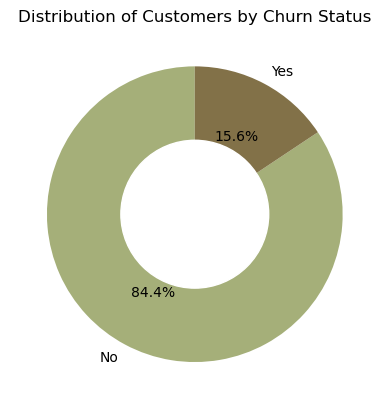

In [11]:
# distribution of customers by churn status
plt.pie(df['Churn'].value_counts(), labels=['No', 'Yes'], colors=['#A5AF79', '#827148'], autopct='%1.1f%%', startangle=90)
circle = plt.Circle((0, 0), 0.5, color='white')
plt.gca().add_artist(circle)
plt.title("Distribution of Customers by Churn Status")
plt.show()


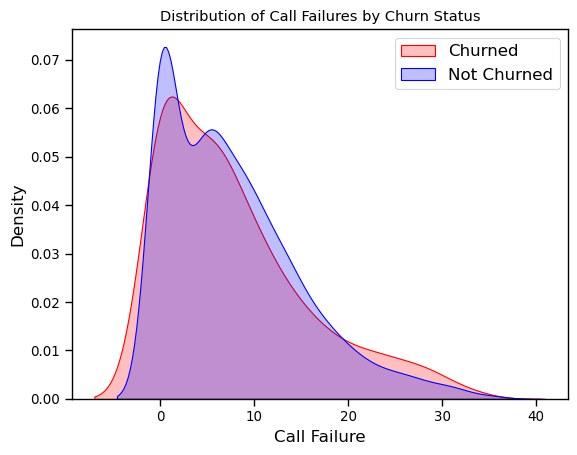

In [12]:
# distribution of customer churn class by call failure
sns.set_context("paper", font_scale=1.1)
ax = sns.kdeplot(df["Call Failure"][(df.Churn == 1)], color='r', fill=True)
ax = sns.kdeplot(df["Call Failure"][(df.Churn == 0)], color='b', fill=True)

ax.set_xlabel('Call Failure', fontsize=12)
ax.legend(['Churned', 'Not Churned'], fontsize=12)
ax.set_ylabel('Density', fontsize=12)
plt.title("Distribution of Call Failures by Churn Status")
plt.show()

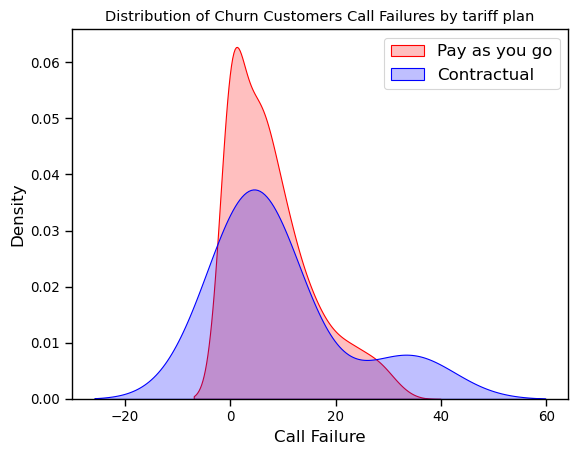

In [13]:
# create a new dataframe for churn customers
churn_df = df[df["Churn"] == 1]

# distribution of customer churn class by call failure
sns.set_context("paper", font_scale=1.1)
ax = sns.kdeplot(churn_df["Call Failure"][(churn_df["Tariff Plan"] == 1)], color='r', fill=True)
ax = sns.kdeplot(churn_df["Call Failure"][(churn_df["Tariff Plan"] == 2)], color='b', fill=True)

ax.set_xlabel('Call Failure', fontsize=12)
ax.legend(['Pay as you go', 'Contractual'], fontsize=12)
ax.set_ylabel('Density', fontsize=12)
plt.title("Distribution of Churn Customers Call Failures by tariff plan")
plt.show()

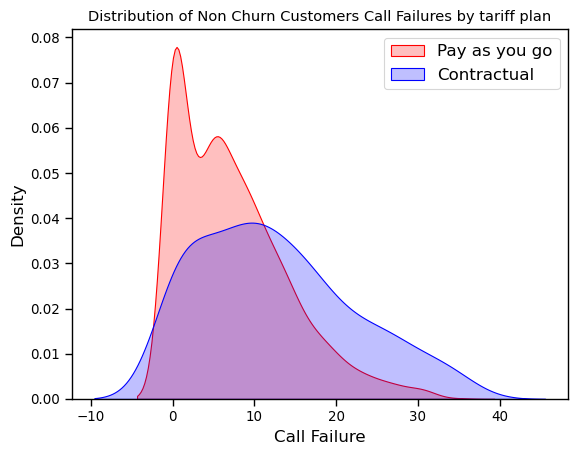

In [14]:
# create a new dataframe for non churn customers
nonchurn_df = df[df["Churn"] == 0]

# distribution of customer churn class by call failure
sns.set_context("paper", font_scale=1.1)
ax = sns.kdeplot(nonchurn_df["Call Failure"][(nonchurn_df["Tariff Plan"] == 1)], color='r', fill=True)
ax = sns.kdeplot(nonchurn_df["Call Failure"][(nonchurn_df["Tariff Plan"] == 2)], color='b', fill=True)

ax.set_xlabel('Call Failure', fontsize=12)
ax.legend(['Pay as you go', 'Contractual'], fontsize=12)
ax.set_ylabel('Density', fontsize=12)
plt.title("Distribution of Non Churn Customers Call Failures by tariff plan")
plt.show()

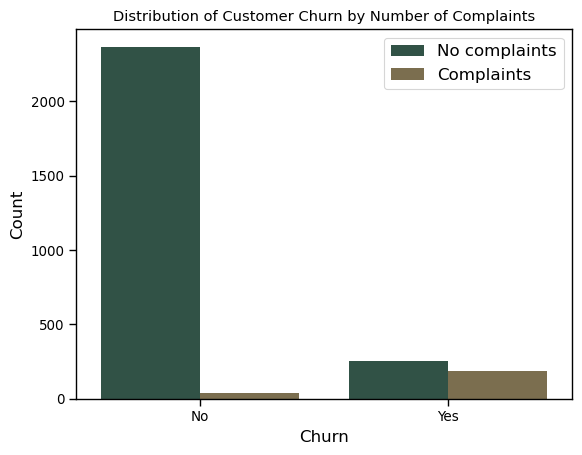

In [15]:
#distribution of customer churn class by complaints
sns.countplot(x='Churn', hue='Complains', data=df, palette=['#2B5748', '#827148'])
plt.xlabel('Churn', fontsize=12)
plt.xticks([0, 1], ['No', 'Yes'])
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Customer Churn by Number of Complaints')
plt.legend(['No complaints', 'Complaints'], fontsize=12)
plt.show()

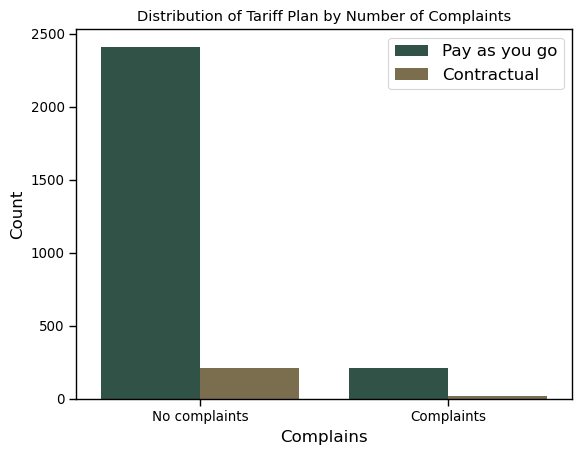

In [16]:
#distribution of customer churn class by complaints
sns.countplot(x='Complains', hue='Tariff Plan', data=df, palette=['#2B5748', '#827148'])
plt.xlabel('Complains', fontsize=12)
plt.xticks([0, 1], ['No complaints', 'Complaints'])
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Tariff Plan by Number of Complaints')
plt.legend(['Pay as you go', 'Contractual'], fontsize=12)
plt.show()

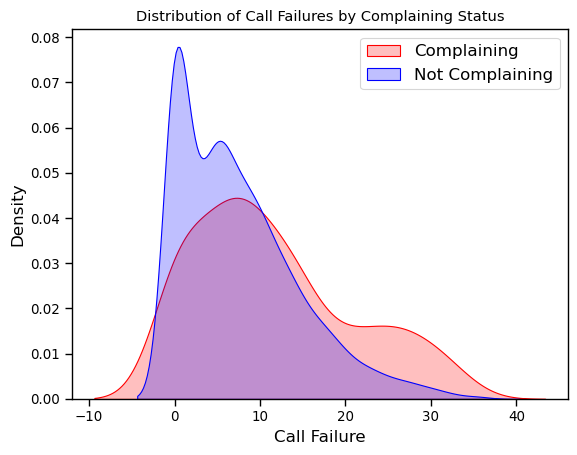

In [17]:
# Relationship between call failure and complains
sns.set_context("paper", font_scale=1.1)
ax = sns.kdeplot(df["Call Failure"][(df.Complains == 1)], color='r', fill=True)
ax = sns.kdeplot(df["Call Failure"][(df.Complains == 0)], color='b', fill=True)

ax.set_xlabel('Call Failure', fontsize=12)
ax.legend(['Complaining', 'Not Complaining'], fontsize=12)
ax.set_ylabel('Density', fontsize=12)
plt.title("Distribution of Call Failures by Complaining Status")
plt.show()

In [18]:
print("churn customers that complain:", len(churn_df[churn_df["Complains"] == 1]) / len(churn_df) * 100)
print("churn customers that don't complain:", len(churn_df[churn_df["Complains"] == 0]) / len(churn_df) * 100)
print("Total customers that complain::", len(df[df["Complains"] == 1]) / len(df) * 100)
print("Total customers that don't complain:", len(df[df["Complains"] == 0]) / len(df) * 100)
print("percentage of churn customers that complain:", len(churn_df[churn_df["Complains"] == 1]) / len(df[df["Complains"] == 1]) * 100)
print("revenue lost due to churn customers that complain:", churn_df[churn_df["Complains"] == 1]["Customer Value"].sum())
print("revenue lost due to churn customers that don't complain:", churn_df[churn_df["Complains"] == 0]["Customer Value"].sum())




churn customers that complain: 42.600896860986545
churn customers that don't complain: 57.399103139013455
Total customers that complain:: 8.070175438596491
Total customers that don't complain: 91.9298245614035
percentage of churn customers that complain: 82.6086956521739
revenue lost due to churn customers that complain: 32493.915
revenue lost due to churn customers that don't complain: 26456.445


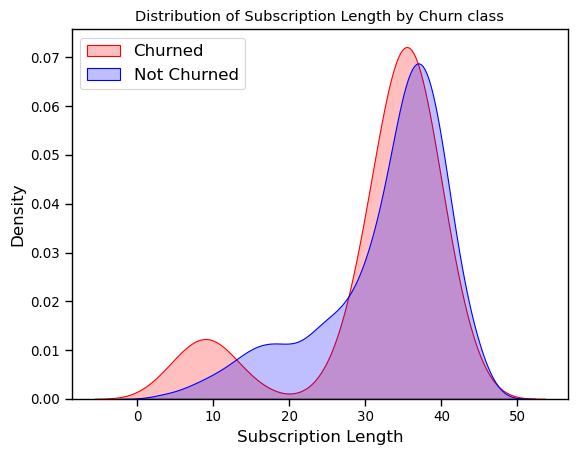

In [19]:
# distribution of customer churn class by subscription lenghth
sns.set_context("paper", font_scale=1.1)
ax = sns.kdeplot(df["Subscription Length"][(df.Churn == 1)], color='r', fill=True)
ax = sns.kdeplot(df["Subscription Length"][(df.Churn == 0)], color='b', fill=True)

ax.set_xlabel('Subscription Length', fontsize=12)
ax.legend(['Churned', 'Not Churned'], fontsize=12)
ax.set_ylabel('Density', fontsize=12)
plt.title("Distribution of Subscription Length by Churn class")
plt.show()

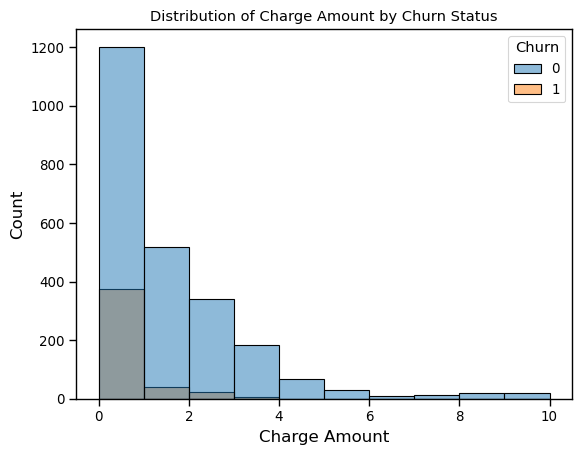

In [20]:
# distribution of customer churn class by Charge Amount
sns.histplot(x='Charge Amount', data=df, hue='Churn', bins=10)
plt.xlabel('Charge Amount', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title("Distribution of Charge Amount by Churn Status")
plt.show()

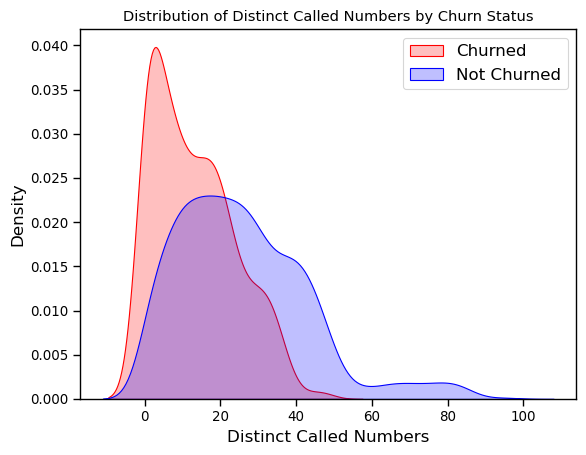

In [21]:
# distribution of customer churn class by Distinct Called Numbers
sns.set_context("paper", font_scale=1.1)
ax = sns.kdeplot(df["Distinct Called Numbers"][(df.Churn == 1)], color='r', fill=True)
ax = sns.kdeplot(df["Distinct Called Numbers"][(df.Churn == 0)], color='b', fill=True)

ax.set_xlabel('Distinct Called Numbers', fontsize=12)
ax.legend(['Churned', 'Not Churned'], fontsize=12)
ax.set_ylabel('Density', fontsize=12)
plt.title("Distribution of Distinct Called Numbers by Churn Status")
plt.show()

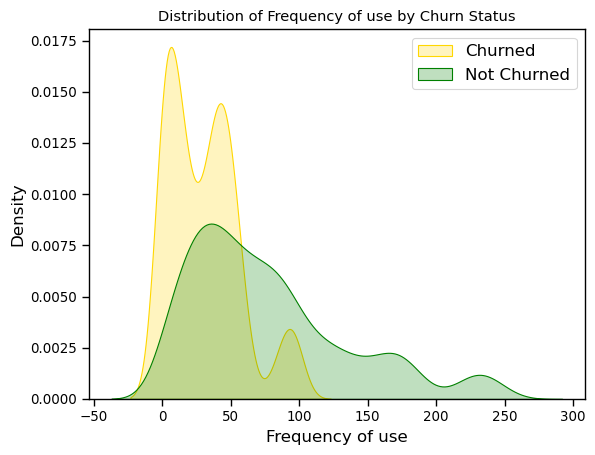

In [22]:
# distribution of customer churn class by Frequency of use
sns.set_context("paper", font_scale=1.1)
ax = sns.kdeplot(df["Frequency of use"][(df.Churn == 1)], color='gold', fill=True)
ax = sns.kdeplot(df["Frequency of use"][(df.Churn == 0)], color='green', fill=True)

ax.set_xlabel('Frequency of use', fontsize=12)
ax.legend(['Churned', 'Not Churned'], fontsize=12)
ax.set_ylabel('Density', fontsize=12)
plt.title("Distribution of Frequency of use by Churn Status")
plt.show()

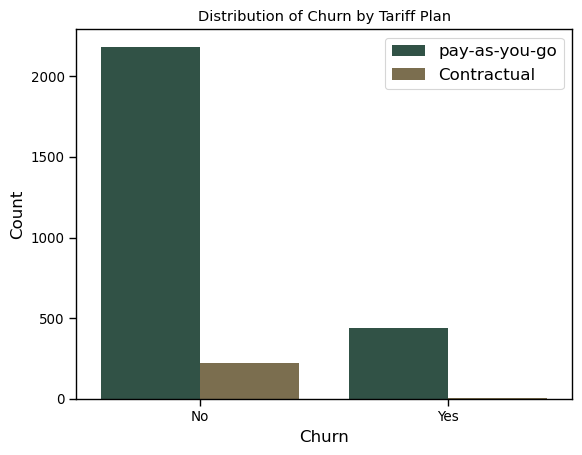

In [23]:
# distribution of churn class by tariff plan
sns.set_context("paper", font_scale=1.1)
sns.countplot(x='Churn', hue='Tariff Plan', data=df, palette=['#2B5748', '#827148'])
plt.xlabel('Churn', fontsize=12)
plt.xticks([0, 1], ['No', 'Yes'])
plt.ylabel('Count', fontsize=12)
plt.legend(['pay-as-you-go', 'Contractual'], fontsize=12)
plt.title('Distribution of Churn by Tariff Plan')
plt.show()

In [24]:
print("churn customers that uses pay as you go tariff:", len(churn_df[churn_df["Tariff Plan"] == 1]) / len(churn_df) * 100)
print("churn customers that don't use pay as you go tariff:", len(churn_df[churn_df["Tariff Plan"] == 2]) / len(churn_df) * 100)
print("Total customers that use pay as you go tariff:", len(df[df["Tariff Plan"] == 1]) / len(df) * 100)
print("Total customers that don't use pay as you go tariff:", len(df[df["Tariff Plan"] == 2]) / len(df) * 100)
print("percentage of churn customers that use pay as you go tariff:", len(churn_df[churn_df["Tariff Plan"] == 1]) / len(df[df["Tariff Plan"] == 1]) * 100)
print("revenue lost due to churn customers that use pay as you go tariff:", churn_df[churn_df["Tariff Plan"] == 1]["Customer Value"].sum())
print("revenue lost due to churn customers that don't use pay as you go tariff:", churn_df[churn_df["Tariff Plan"] == 2]["Customer Value"].sum())


churn customers that uses pay as you go tariff: 98.65470852017937
churn customers that don't use pay as you go tariff: 1.345291479820628
Total customers that use pay as you go tariff: 91.96491228070175
Total customers that don't use pay as you go tariff: 8.035087719298245
percentage of churn customers that use pay as you go tariff: 16.787485692483788
revenue lost due to churn customers that use pay as you go tariff: 54107.979999999996
revenue lost due to churn customers that don't use pay as you go tariff: 4842.38


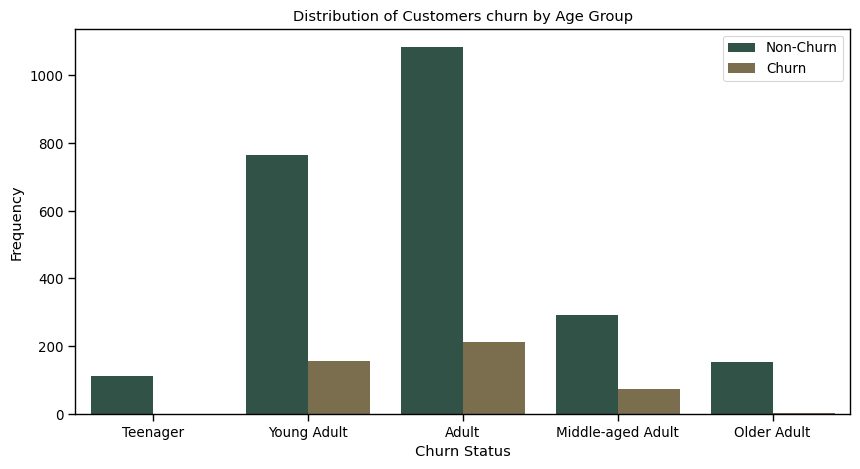

In [25]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="Age Group", hue="Churn", palette=['#2B5748', '#827148'])
plt.xlabel("Churn Status")
plt.xticks([0,1,2,3,4], ["Teenager", "Young Adult", "Adult", "Middle-aged Adult", "Older Adult"])
plt.ylabel("Frequency")
plt.title("Distribution of Customers churn by Age Group")
plt.legend(labels = ["Non-Churn", "Churn"])
plt.show()

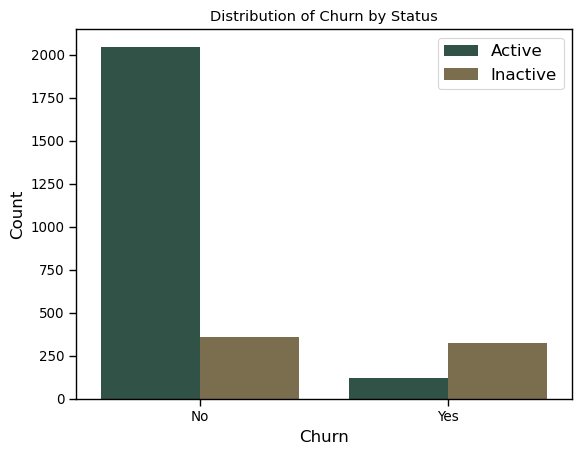

In [26]:
# distribution of churn class by status
sns.set_context("paper", font_scale=1.1)
sns.countplot(x='Churn', hue='Status', data=df, palette=['#2B5748', '#827148'])
plt.xlabel('Churn', fontsize=12)
plt.xticks([0, 1], ['No', 'Yes'])
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Churn by Status')
plt.legend(['Active', 'Inactive'], fontsize=12)
plt.show()

In [27]:
print("churn customers that are inactive:", len(churn_df[churn_df["Status"] == 2]) / len(churn_df) * 100)
print("churn customers that are active:", len(churn_df[churn_df["Status"] == 1]) / len(churn_df) * 100)
print("Total customers that are inactive::", len(df[df["Status"] == 2]) / len(df) * 100)
print("Total customers that are active:", len(df[df["Status"] == 1]) / len(df) * 100)
print("percentage of churn customers that are inactive:", len(churn_df[churn_df["Status"] == 2]) / len(df[df["Status"] == 2]) * 100)
print("revenue lost due to churn customers that are inactive:", churn_df[churn_df["Status"] == 2]["Customer Value"].sum())
print("revenue lost due to churn customers that are active:", churn_df[churn_df["Status"] == 1]["Customer Value"].sum())



churn customers that are inactive: 72.86995515695067
churn customers that are active: 27.130044843049326
Total customers that are inactive:: 24.0
Total customers that are active: 76.0
percentage of churn customers that are inactive: 47.514619883040936
revenue lost due to churn customers that are inactive: 35235.715000000004
revenue lost due to churn customers that are active: 23714.645000000004


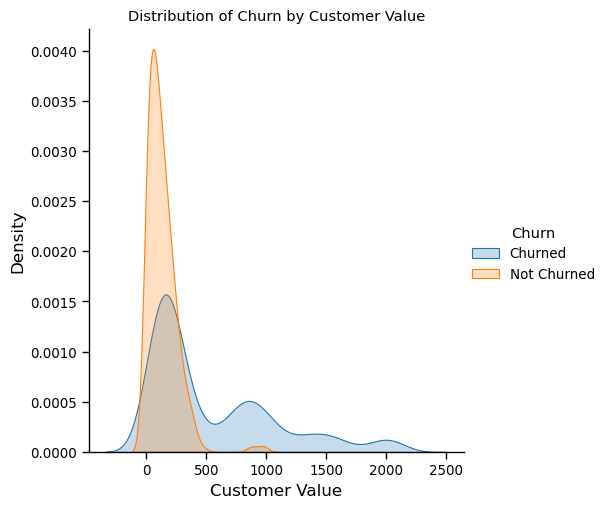

In [28]:
# distribution of churn class by customer value
sns.set_context("paper", font_scale=1.1)
sns.FacetGrid(df, hue="Churn", height=5).map(sns.kdeplot, "Customer Value", fill=True).add_legend(labels=['Churned', 'Not Churned'])
plt.xlabel('Customer Value', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Distribution of Churn by Customer Value')
plt.show()

In [29]:
print("churn customers having less than $500:", len(churn_df[churn_df["Customer Value"] < 500]) / len(churn_df * 100))
print("churn customers having more than $500:", len(churn_df[churn_df["Customer Value"] > 500]) / len(churn_df * 100))
print("Total customers having less than $500:", len(df[df["Customer Value"] < 500]) / len(df * 100))
print("Total customers having more than $500:", len(df[df["Customer Value"] > 500]) / len(df * 100))
print("percentage of churn customers having less than $500:", len(churn_df[churn_df["Customer Value"] < 500]) / len(df[df["Customer Value"] < 500]) * 100)




churn customers having less than $500: 0.9887892376681614
churn customers having more than $500: 0.011210762331838564
Total customers having less than $500: 0.6740350877192982
Total customers having more than $500: 0.32596491228070174
percentage of churn customers having less than $500: 22.95679333680375


**Data Preprocessing**

In [30]:
X = df.drop(['Churn'], axis=1)
y = df['Churn']

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [32]:
def train_model(model, X_train, y_train):
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)

    cv_acc_score = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    cv_auc_score = cross_val_score(model, X_train, y_train, cv=kfold, scoring='roc_auc')

    print(f"Cross-validated Accuracy: {np.mean(cv_acc_score):.4f} ± {np.std(cv_acc_score):.4f}")
    print(f"Cross-validated AUC: {np.mean(cv_auc_score):.4f} ± {np.std(cv_auc_score):.4f}")


In [33]:
for model in [LogisticRegression(max_iter=1000), RandomForestClassifier(random_state=42), xgb(random_state=42)]:
    print(f"Training {model.__class__.__name__}...")
    train_model(model, X_train, y_train)
    print("\n")
    

Training LogisticRegression...


c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Cross-validated Accuracy: 0.8978 ± 0.0063
Cross-validated AUC: 0.9339 ± 0.0170


Training RandomForestClassifier...
Cross-validated Accuracy: 0.9553 ± 0.0069
Cross-validated AUC: 0.9838 ± 0.0025


Training XGBClassifier...
Cross-validated Accuracy: 0.9566 ± 0.0075
Cross-validated AUC: 0.9841 ± 0.0022




In [34]:
# Find the optimal number of estimators for the Random Forest model
scores = []

for i in range(50, 100):
    rf_model = RandomForestClassifier(n_estimators=i, random_state=42)
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)
    acc = np.mean(y_pred == y_test)
    scores.append(acc)

In [35]:
# Print the accuracy scores for each number of estimators
for i,j in enumerate(scores):
    print(f"n_estimators: {i+50}, Accuracy: {j:.4f}")

n_estimators: 50, Accuracy: 0.9561
n_estimators: 51, Accuracy: 0.9596
n_estimators: 52, Accuracy: 0.9561
n_estimators: 53, Accuracy: 0.9596
n_estimators: 54, Accuracy: 0.9596
n_estimators: 55, Accuracy: 0.9614
n_estimators: 56, Accuracy: 0.9596
n_estimators: 57, Accuracy: 0.9632
n_estimators: 58, Accuracy: 0.9614
n_estimators: 59, Accuracy: 0.9614
n_estimators: 60, Accuracy: 0.9614
n_estimators: 61, Accuracy: 0.9614
n_estimators: 62, Accuracy: 0.9596
n_estimators: 63, Accuracy: 0.9596
n_estimators: 64, Accuracy: 0.9579
n_estimators: 65, Accuracy: 0.9596
n_estimators: 66, Accuracy: 0.9596
n_estimators: 67, Accuracy: 0.9596
n_estimators: 68, Accuracy: 0.9614
n_estimators: 69, Accuracy: 0.9632
n_estimators: 70, Accuracy: 0.9632
n_estimators: 71, Accuracy: 0.9632
n_estimators: 72, Accuracy: 0.9632
n_estimators: 73, Accuracy: 0.9632
n_estimators: 74, Accuracy: 0.9649
n_estimators: 75, Accuracy: 0.9632
n_estimators: 76, Accuracy: 0.9649
n_estimators: 77, Accuracy: 0.9632
n_estimators: 78, Ac

In [36]:
def create_confusion_matrix(model, X_test, y_test):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix for {model.__class__.__name__}')
    plt.show()

In [37]:
model = RandomForestClassifier(n_estimators=74, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=74, random_state=42)

In [38]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['Not Churned', 'Churned']))

              precision    recall  f1-score   support

 Not Churned       0.97      0.99      0.98       481
     Churned       0.94      0.83      0.88        89

    accuracy                           0.96       570
   macro avg       0.95      0.91      0.93       570
weighted avg       0.96      0.96      0.96       570



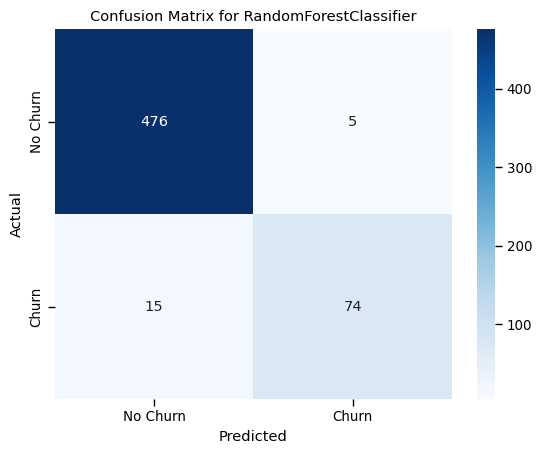

In [39]:
create_confusion_matrix(model, X_test, y_test)

In [40]:
logreg_model = LogisticRegression(max_iter=1000)
logreg_model.fit(X_train, y_train)

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [41]:
lg_y_pred = logreg_model.predict(X_test)
print(classification_report(y_test, lg_y_pred, target_names=['Not Churned', 'Churned']))

              precision    recall  f1-score   support

 Not Churned       0.91      0.98      0.94       481
     Churned       0.78      0.48      0.60        89

    accuracy                           0.90       570
   macro avg       0.85      0.73      0.77       570
weighted avg       0.89      0.90      0.89       570



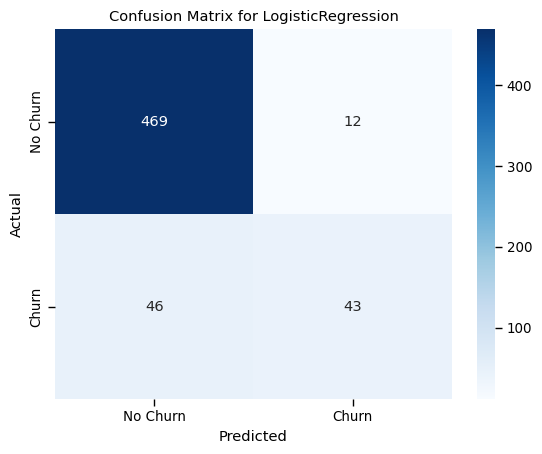

In [42]:
create_confusion_matrix(logreg_model, X_test, y_test)

In [43]:
scores = []

for i in range(100, 200):
    x_model = xgb(n_estimators=i, random_state=42)
    x_model.fit(X_train, y_train)
    y_pred = x_model.predict(X_test)
    acc = np.mean(y_pred == y_test)
    scores.append(acc)

In [44]:
for i,j in enumerate(scores):
    print(f"n_estimators: {i+100}, Accuracy: {j:.4f}")

n_estimators: 100, Accuracy: 0.9596
n_estimators: 101, Accuracy: 0.9596
n_estimators: 102, Accuracy: 0.9596
n_estimators: 103, Accuracy: 0.9596
n_estimators: 104, Accuracy: 0.9596
n_estimators: 105, Accuracy: 0.9596
n_estimators: 106, Accuracy: 0.9596
n_estimators: 107, Accuracy: 0.9596
n_estimators: 108, Accuracy: 0.9596
n_estimators: 109, Accuracy: 0.9596
n_estimators: 110, Accuracy: 0.9596
n_estimators: 111, Accuracy: 0.9596
n_estimators: 112, Accuracy: 0.9596
n_estimators: 113, Accuracy: 0.9596
n_estimators: 114, Accuracy: 0.9596
n_estimators: 115, Accuracy: 0.9596
n_estimators: 116, Accuracy: 0.9596
n_estimators: 117, Accuracy: 0.9596
n_estimators: 118, Accuracy: 0.9596
n_estimators: 119, Accuracy: 0.9614
n_estimators: 120, Accuracy: 0.9596
n_estimators: 121, Accuracy: 0.9614
n_estimators: 122, Accuracy: 0.9614
n_estimators: 123, Accuracy: 0.9614
n_estimators: 124, Accuracy: 0.9614
n_estimators: 125, Accuracy: 0.9614
n_estimators: 126, Accuracy: 0.9614
n_estimators: 127, Accuracy:

In [45]:
x_model = xgb(n_estimators=121, max_depth=20, learning_rate=0.1, subsample=0.8, random_state=42)

x_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=20,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=121,
              n_jobs=None, num_parallel_tree=None, ...)

In [46]:
x_y_pred = x_model.predict(X_test)

print(classification_report(y_test, x_y_pred, target_names=['Not Churned', 'Churned']))

              precision    recall  f1-score   support

 Not Churned       0.98      0.98      0.98       481
     Churned       0.89      0.87      0.88        89

    accuracy                           0.96       570
   macro avg       0.93      0.92      0.93       570
weighted avg       0.96      0.96      0.96       570



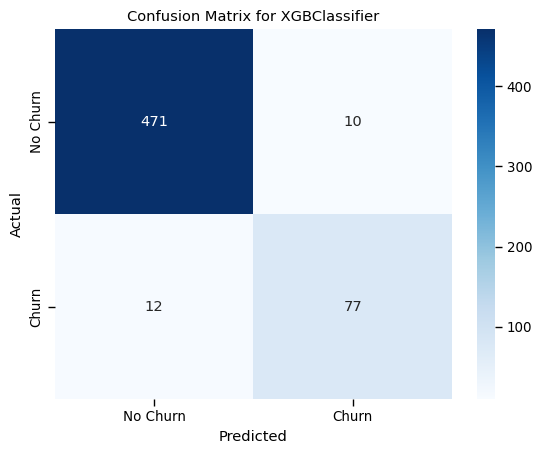

In [47]:
create_confusion_matrix(x_model, X_test, y_test)

**Model with oversampling**

In [48]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

In [49]:
log_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('logreg', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

log_pipeline.fit(X_train, y_train)

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('logreg',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [50]:
log_pipe_y_pred = log_pipeline.predict(X_test)

print(classification_report(y_test, log_pipe_y_pred, target_names=['Not Churned', 'Churned']))

              precision    recall  f1-score   support

 Not Churned       0.97      0.81      0.88       481
     Churned       0.45      0.84      0.59        89

    accuracy                           0.81       570
   macro avg       0.71      0.83      0.73       570
weighted avg       0.88      0.81      0.83       570



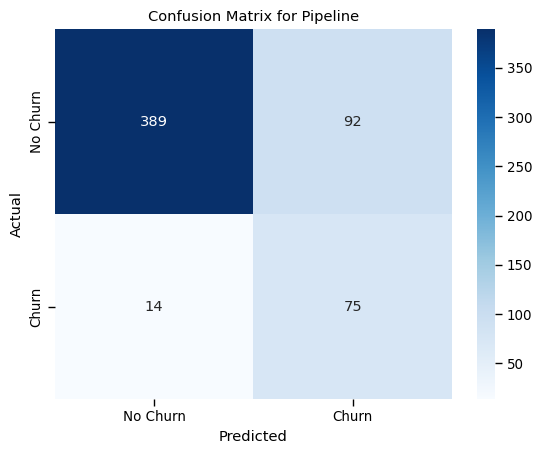

In [51]:
create_confusion_matrix(log_pipeline, X_test, y_test)

In [52]:
rfc_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rfc', RandomForestClassifier(n_estimators=74, random_state=42))
])
rfc_pipeline.fit(X_train, y_train)

Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('rfc',
                 RandomForestClassifier(n_estimators=74, random_state=42))])

In [53]:
rfc_pipe_y_pred = rfc_pipeline.predict(X_test)
print(classification_report(y_test, rfc_pipe_y_pred, target_names=['Not Churned', 'Churned']))

              precision    recall  f1-score   support

 Not Churned       0.99      0.96      0.98       481
     Churned       0.82      0.94      0.88        89

    accuracy                           0.96       570
   macro avg       0.91      0.95      0.93       570
weighted avg       0.96      0.96      0.96       570



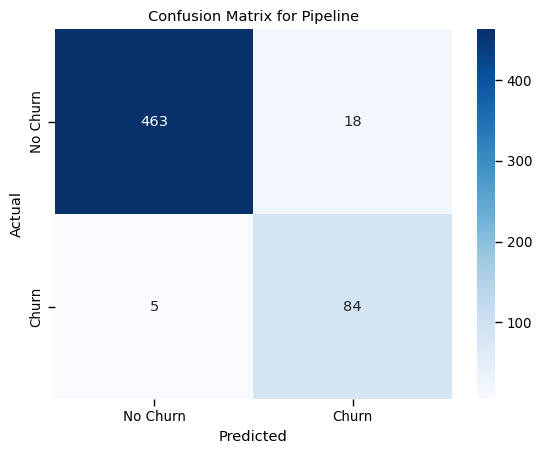

In [54]:
create_confusion_matrix(rfc_pipeline, X_test, y_test)

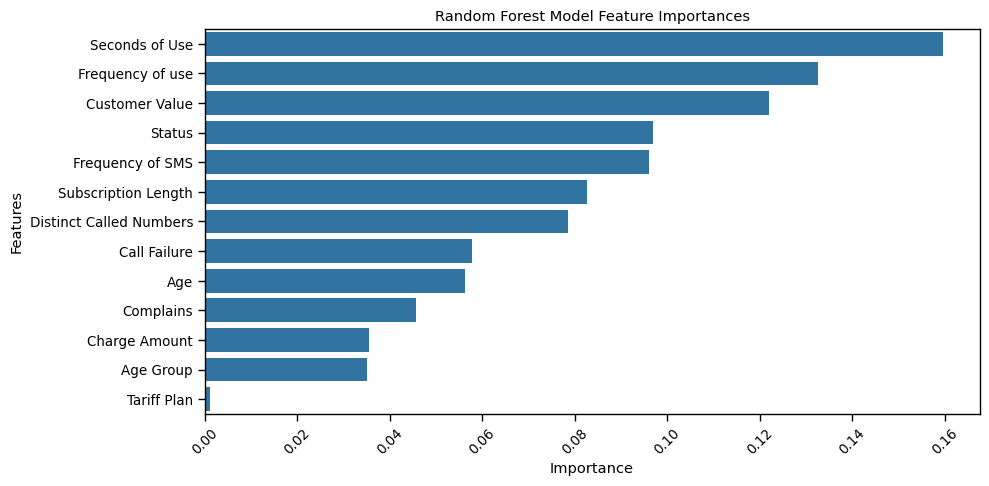

In [55]:
rfcfeature_importances = pd.DataFrame(rfc_pipeline.named_steps['rfc'].feature_importances_, index=X_train.columns, columns=['importance']).sort_values('importance', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(data=rfcfeature_importances, y=rfcfeature_importances.index, x='importance', orient='h')
plt.xticks(rotation=45)
plt.title('Random Forest Model Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

In [56]:
x_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', xgb(n_estimators=200, max_depth=25, learning_rate=0.1, subsample=0.8, random_state=42))
])

x_pipeline.fit(X_train, y_train)

Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('xgb',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=True, eval_metric=None,
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=25, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [57]:
x_pipe_y_pred = x_pipeline.predict(X_test)

print(classification_report(y_test, x_pipe_y_pred, target_names=['Not Churned', 'Churned']))

              precision    recall  f1-score   support

 Not Churned       0.99      0.97      0.98       481
     Churned       0.84      0.93      0.88        89

    accuracy                           0.96       570
   macro avg       0.91      0.95      0.93       570
weighted avg       0.96      0.96      0.96       570



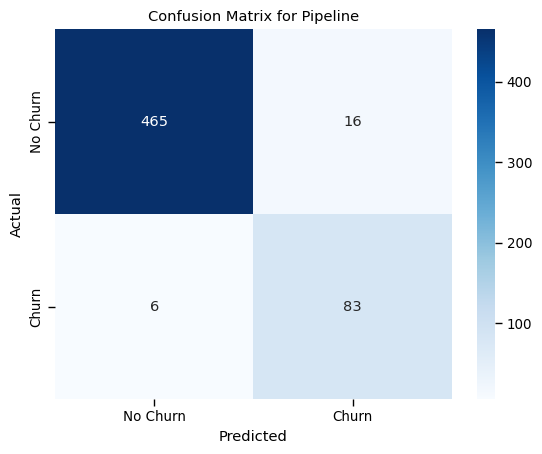

In [58]:
create_confusion_matrix(x_pipeline, X_test, y_test)

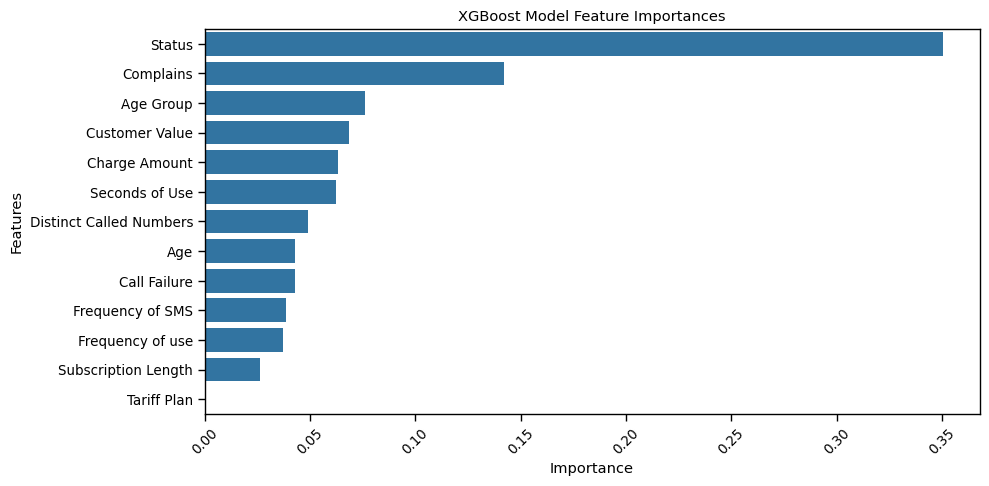

In [59]:
xgbfeature_importances = pd.DataFrame(x_pipeline.named_steps['xgb'].feature_importances_, index=X_train.columns, columns=['importance']).sort_values('importance', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(data=xgbfeature_importances, y=xgbfeature_importances.index, x='importance', orient='h')
plt.xticks(rotation=45)
plt.title('XGBoost Model Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

In [60]:
final_model = x_pipeline

In [61]:
pickle.dump(final_model, open('final_model.pkl', 'wb'))

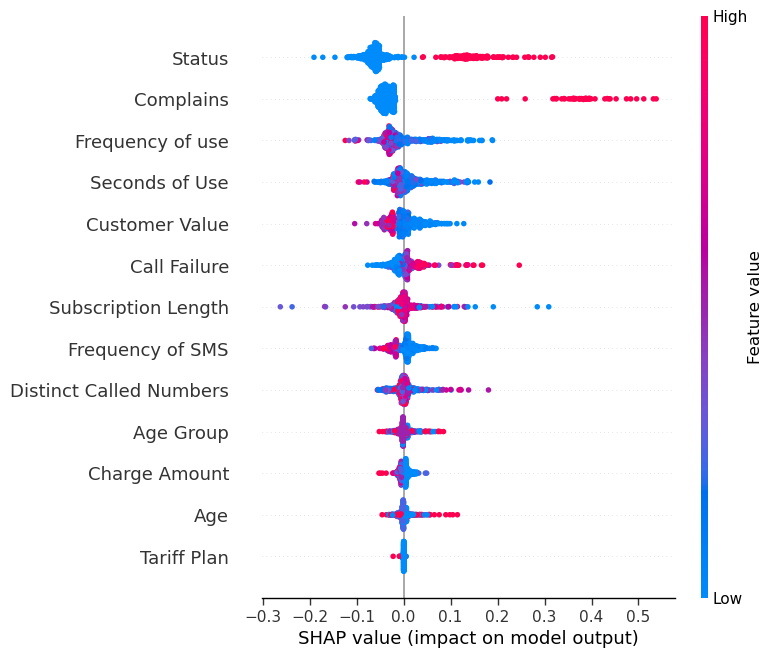

In [65]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Global feature importance — which features matter most overall
shap.summary_plot(shap_values[:,:,1], X_test)  # [1] = churn class for classifiers

In [68]:
pickle.dump(explainer, open('shap_explainer.pkl', 'wb'))